In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from matplotlib.colors import LinearSegmentedColormap
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
import scipy

In [12]:
# generate training data
def target(x):
    """
    Function to optimise
    """
    f = np.sin( 3 * np.pi * x**3) - 0.5 * np.sin(8 * np.pi * x**3)
    return f

def phi(x):
    return scipy.stats.norm.pdf(x)

def Phi(x):
    return scipy.stats.norm.cdf(x)

def EI(mu, sigma, f_best):
    s = (f_best - mu)/sigma
    return (sigma*s * Phi(s) + sigma*phi(s))
    
def PI(mu, sigma,f_best):
    s = (f_best - mu)/sigma
    return (Phi(s))

def LCB(mu, sigma,beta):
    return (mu - beta*sigma)

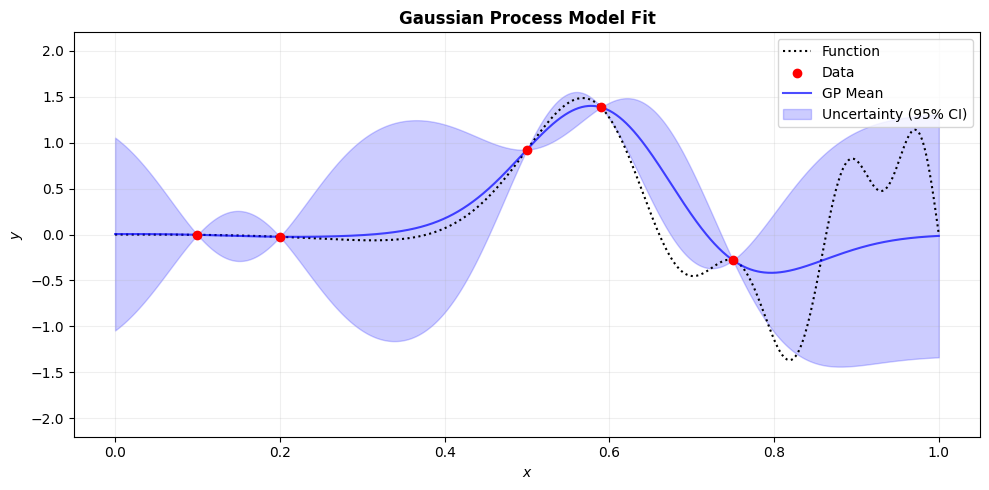

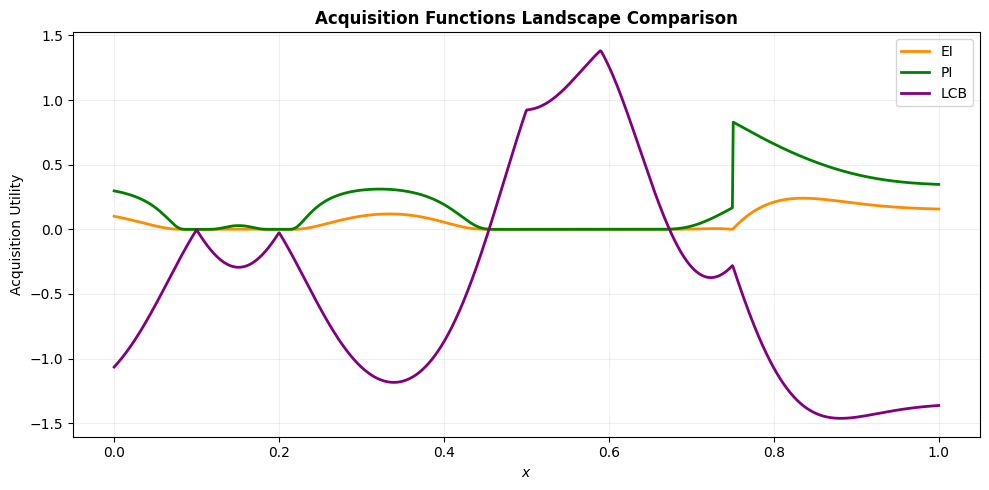

In [26]:
X_train = [0.1,  0.5,  0.75, 0.2, 0.59]
X_train = np.atleast_2d(np.asarray(X_train)).T
y_train = target(X_train)

kernel = 1 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
gaussian_process.fit(X_train, y_train)

X_test = np.linspace(0,1,1000)
X_test = np.atleast_2d(np.asarray(X_test)).T
y_test = target(X_test)

mean_prediction, std_prediction = gaussian_process.predict(X_test, return_std=True)


# 2. Render and Save Model Plot
# Force exact standardized sizing
fig1, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(X_test, y_test, label='Function', linestyle="dotted", color='black')
ax1.scatter(X_train, y_train, color='red', zorder=5, label="Data")
ax1.plot(X_test, mean_prediction, 'b-', alpha=0.7, label='GP Mean')

ax1.fill_between(
    X_test.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.2,
    color='blue',
    label=r"Uncertainty (95% CI)",
)

ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-2.2, 2.2)
ax1.legend(loc='upper right')
ax1.set_xlabel("$x$")
ax1.set_ylabel("$y$")
ax1.set_title("Gaussian Process Model Fit", fontsize=12, weight='bold')
ax1.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('model.pdf', format='pdf', bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 5))

ax2.plot(X_test, EI_data, label='EI', color='darkorange', lw=2)
ax2.plot(X_test, PI_data, label='PI', color='green', lw=2)
ax2.plot(X_test, LCB_data, label='LCB', color='purple', lw=2)

ax2.set_xlim(-0.05, 1.05)
ax2.legend(loc='upper right')
ax2.set_xlabel("$x$")
ax2.set_ylabel("Acquisition Utility")
ax2.set_title("Acquisition Functions Landscape Comparison", fontsize=12, weight='bold')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('af_landscape.pdf', format='pdf', bbox_inches='tight')
plt.show()

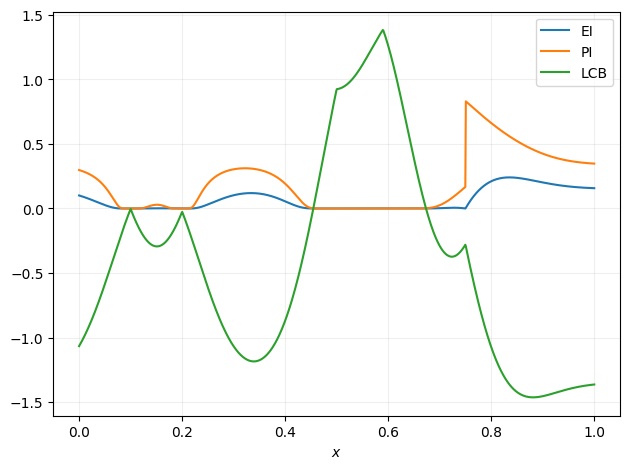

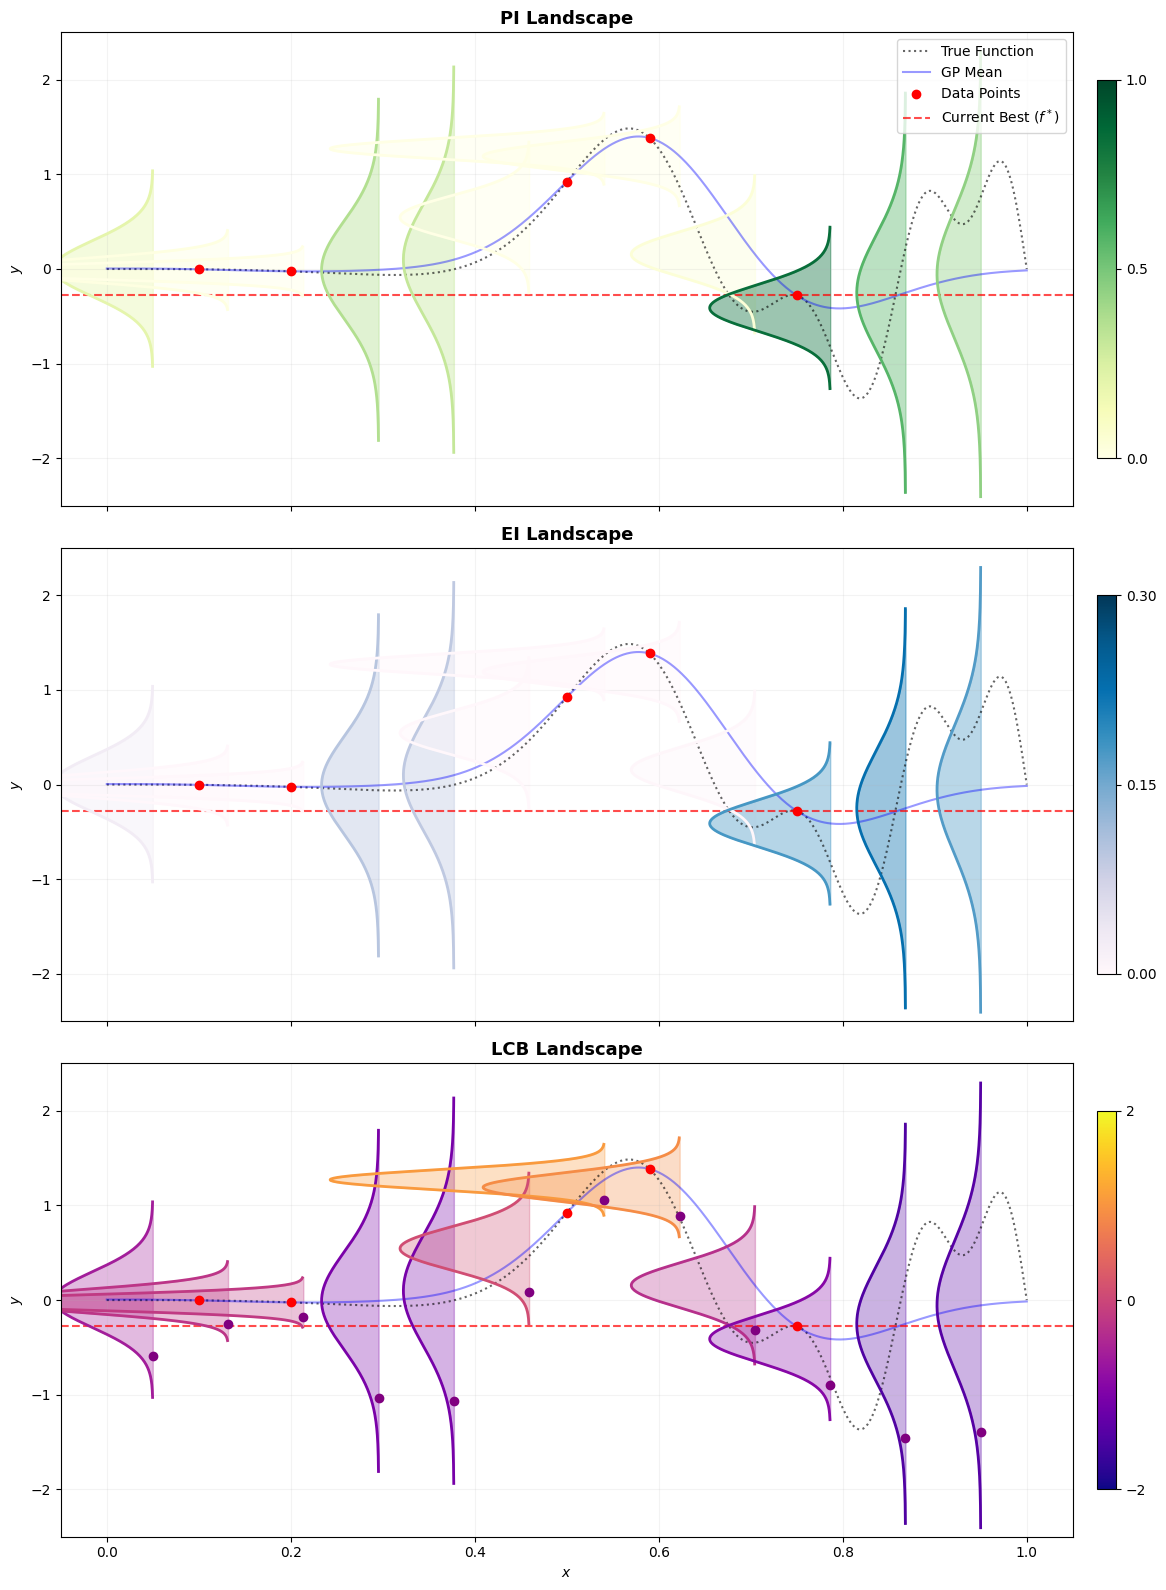

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from matplotlib.colors import LinearSegmentedColormap

# =====================================================================
# 1. Setup Ground Truth & Acquisition Functions
# =====================================================================
def target(x):
    return np.sin(3 * np.pi * x**3) - 0.5 * np.sin(8 * np.pi * x**3)

def phi(x): return scipy.stats.norm.pdf(x)
def Phi(x): return scipy.stats.norm.cdf(x)

def calc_EI(mu, sigma, f_best):
    s = (f_best - mu) / sigma
    return sigma * s * Phi(s) + sigma * phi(s)
    
def calc_PI(mu, sigma, f_best):
    s = (f_best - mu) / sigma
    return Phi(s)

def calc_LCB(mu, sigma, beta=2.0):
    return mu - beta * sigma

# =====================================================================
# 2. Train Gaussian Process Model
# =====================================================================
X_train = np.array([0.1, 0.5, 0.75, 0.2, 0.59]).reshape(-1, 1)
y_train = target(X_train).reshape(-1)

kernel = 1 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
gaussian_process.fit(X_train, y_train)

X_test = np.linspace(0, 1, 1000).reshape(-1, 1)
y_test = target(X_test).reshape(-1)
mean_prediction, std_prediction = gaussian_process.predict(X_test, return_std=True)
f_best = np.min(y_train)

# =====================================================================
# 3. Setup Multi-Distribution (Ridge) Plotting Engine
# =====================================================================
x_slices = np.linspace(0.05, 0.95, 12)
X_slices_2d = x_slices.reshape(-1, 1)
slice_means, slice_stds = gaussian_process.predict(X_slices_2d, return_std=True)

# FIXED: Exact case-sensitive Matplotlib colormap string identifiers
cmap_pi = plt.colormaps['YlGn']    
cmap_ei = plt.colormaps['PuBu']    
cmap_lcb = plt.colormaps['plasma'] 

fig, axes = plt.subplots(3, 1, figsize=(13, 16), sharex=True, sharey=True)
titles = ["PI Landscape", "EI Landscape", "LCB Landscape"]

scale_factor = 0.08  

for idx, ax in enumerate(axes):
    # Plot true function and baseline elements
    ax.plot(X_test, y_test, 'k:', alpha=0.6, label='True Function')
    ax.plot(X_test, mean_prediction, 'b-', alpha=0.4, label='GP Mean')
    ax.scatter(X_train, y_train, color='red', zorder=5, label='Data Points')
    ax.axhline(f_best, color='red', linestyle='--', alpha=0.7, label=r'Current Best ($f^*$)')
    
    # Pre-calculate bounds across slices to calibrate the colorbars accurately
    pi_vals = [calc_PI(m, s, f_best) for m, s in zip(slice_means, slice_stds)]
    ei_vals = [calc_EI(m, s, f_best) for m, s in zip(slice_means, slice_stds)]
    lcb_vals = [calc_LCB(m, s, beta=2.0) for m, s in zip(slice_means, slice_stds)]
    
    for i, x_coord in enumerate(x_slices):
        mu = slice_means[i]
        sigma = slice_stds[i]
        
        y_domain = np.linspace(mu - 3.5*sigma, mu + 3.5*sigma, 200)
        pdf_vals = scipy.stats.norm.pdf(y_domain, mu, sigma)
        x_curve = x_coord - pdf_vals * scale_factor
        
        if idx == 0:  # PI Visualization
            # Normalize strictly between 0% and 100% probability
            norm_val = pi_vals[i]
            color = cmap_pi(min(norm_val * 1.2, 1.0)) # Scaled slightly for edge visibility
            ax.plot(x_curve, y_domain, color=color, lw=2)
            ax.fill_betweenx(y_domain, x_coord, x_curve, color=color, alpha=0.4)
            
        elif idx == 1:  # EI Visualization
            # Scale color based on relative performance across observed slices
            norm_val = min(ei_vals[i] / 0.3, 1.0) 
            color = cmap_ei(norm_val)
            ax.plot(x_curve, y_domain, color=color, lw=2)
            ax.fill_betweenx(y_domain, x_coord, x_curve, color=color, alpha=0.4)
            
        elif idx == 2:  # LCB Visualization
            # Map LCB values down to clear spectrum ranges
            norm_val = np.clip((lcb_vals[i] - (-2)) / 4, 0, 1)
            color = cmap_lcb(norm_val)
            ax.plot(x_curve, y_domain, color=color, lw=2)
            ax.fill_betweenx(y_domain, x_coord, x_curve, color=color, alpha=0.3)
            ax.plot(x_coord, lcb_vals[i], 'o', color='purple', markersize=6)
            
    ax.set_title(titles[idx], fontsize=13, weight='bold')
    ax.set_ylabel(r'$y$')
    ax.grid(True, alpha=0.15)
    if idx == 0:
        ax.legend(loc='upper right')

    # =====================================================================
    # ADDING COLORBAR LEGENDS FOR MAX/MIN TRACKING
    # =====================================================================
    if idx == 0:
        sm = plt.cm.ScalarMappable(cmap=cmap_pi, norm=plt.Normalize(vmin=0, vmax=1))
        cbar = fig.colorbar(sm, ax=ax, pad=0.02, shrink=0.8)
        # cbar.set_label('PI', weight='bold')
        cbar.set_ticks([0.0, 0.5, 1.0])
        # cbar.set_ticklabels(['0.0 (MIN / Poor)', '0.5', '1.0 (MAX / Certain)'])
    elif idx == 1:
        sm = plt.cm.ScalarMappable(cmap=cmap_ei, norm=plt.Normalize(vmin=0, vmax=0.3))
        cbar = fig.colorbar(sm, ax=ax, pad=0.02, shrink=0.8)
        # cbar.set_label('EI', weight='bold')
        cbar.set_ticks([0.0, 0.15, 0.3])
        # cbar.set_ticklabels(['0.0 (MIN / No Upside)', '0.15', '0.3+ (MAX / High Reward)'])
    elif idx == 2:
        sm = plt.cm.ScalarMappable(cmap=cmap_lcb, norm=plt.Normalize(vmin=-2, vmax=2))
        cbar = fig.colorbar(sm, ax=ax, pad=0.02, shrink=0.8)
        # cbar.set_label('LCB', weight='bold')
        cbar.set_ticks([-2, 0, 2])
        # Remember: Minimization means lower objective values on y-axis are better!
        # cbar.set_ticklabels(['-2.0 (MAX Utility / Best)', '0.0', '2.0 (MIN Utility / Worst)'])

axes[2].set_xlabel(r'$x$')
axes[2].set_ylim(-2.5, 2.5)
axes[2].set_xlim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('distribution_landscape_with_colorbars.pdf', format='pdf', bbox_inches='tight')
plt.show()